In [27]:
import pandas as pd

df = pd.read_csv("../data/spotify_cleaned_unique_tracks.csv")

df.head()


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic,3.314217


In [3]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          89740 non-null  object 
 1   artists           89740 non-null  object 
 2   album_name        89740 non-null  object 
 3   track_name        89740 non-null  object 
 4   popularity        89740 non-null  int64  
 5   duration_ms       89740 non-null  int64  
 6   explicit          89740 non-null  bool   
 7   danceability      89740 non-null  float64
 8   energy            89740 non-null  float64
 9   key               89740 non-null  int64  
 10  loudness          89740 non-null  float64
 11  mode              89740 non-null  int64  
 12  speechiness       89740 non-null  float64
 13  acousticness      89740 non-null  float64
 14  instrumentalness  89740 non-null  float64
 15  liveness          89740 non-null  float64
 16  valence           89740 non-null  float6

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'duration_min'],
      dtype='object')

In [4]:
df = df.dropna()

In [5]:
df_unique = df.drop_duplicates(subset="track_id")

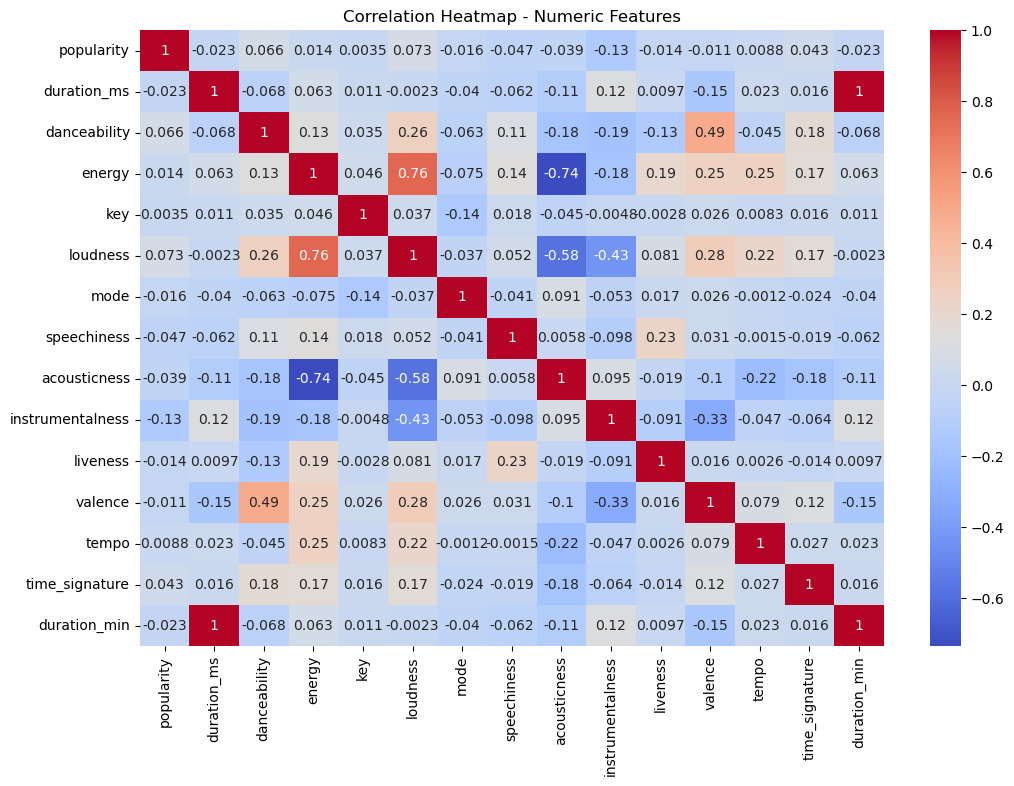

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df_unique.select_dtypes(include="number")

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Numeric Features")
plt.show()

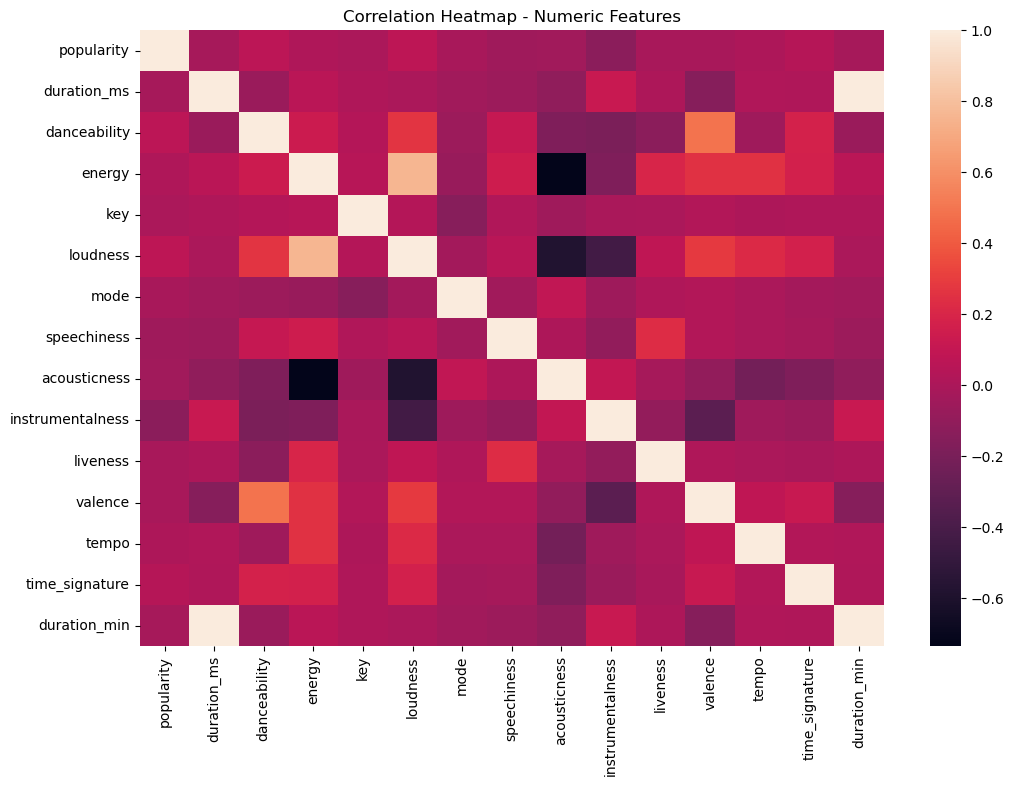

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df_unique.select_dtypes(include="number")

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=False)
plt.title("Correlation Heatmap - Numeric Features")
plt.show()


In [8]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'duration_min'],
      dtype='object')

In [10]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_unique[features])

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_unique["cluster"] = kmeans.fit_predict(X_scaled)

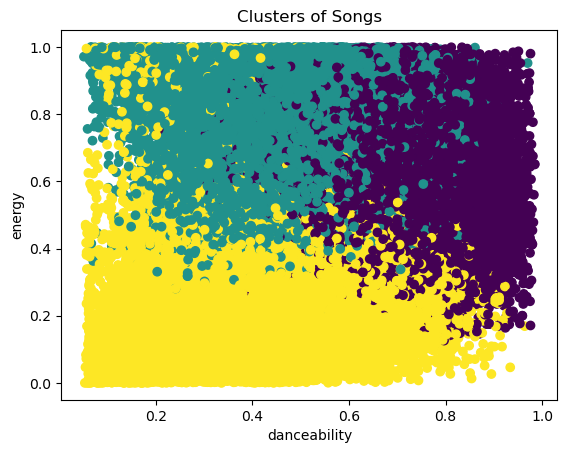

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df_unique["danceability"], df_unique["energy"], c=df_unique["cluster"])
plt.xlabel("danceability")
plt.ylabel("energy")
plt.title("Clusters of Songs")
plt.show()

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_unique["pca1"] = X_pca[:, 0]
df_unique["pca2"] = X_pca[:, 1]

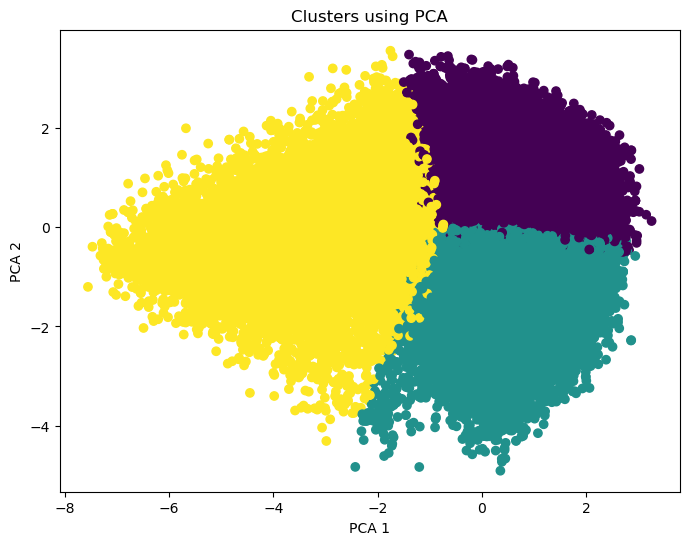

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(df_unique["pca1"], df_unique["pca2"], c=df_unique["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clusters using PCA")
plt.show()

In [18]:
from sklearn.decomposition import PCA
import plotly.express as px

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df_unique["pca1"] = X_pca[:,0]
df_unique["pca2"] = X_pca[:,1]
df_unique["pca3"] = X_pca[:,2]

fig = px.scatter_3d(
    df_unique,
    x="pca1",
    y="pca2",
    z="pca3",
    color=df_unique["cluster"].astype(str)
)

fig.show()

In [19]:
import plotly.express as px

fig = px.scatter_3d(
    df_unique,
    x="pca1",
    y="pca2",
    z="pca3",
    color=df_unique["cluster"].astype(str),
    title="3D Clustering of Songs"
)

fig.write_html("clusters_3d.html")

In [20]:
import webbrowser
webbrowser.open("clusters_3d.html")

True

## 🎧 Cluster Analysis of Songs

In this section, we analyze the clusters created using KMeans to understand how songs differ based on their musical features.

In [21]:
cluster_summary = df_unique.groupby("cluster")[[
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]].mean()

cluster_summary

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.682556,0.680970,-7.116516,0.108671,0.294158,0.055669,0.206045,0.664596,118.052227
1,0.480079,0.806695,-6.041948,0.081199,0.085325,0.214775,0.257633,0.334817,135.791165
2,0.448068,0.274952,-15.048408,0.054400,0.775409,0.346254,0.174091,0.283474,109.847464


In [22]:
cluster_summary.round(2)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.68,0.68,-7.12,0.11,0.29,0.06,0.21,0.66,118.05
1,0.48,0.81,-6.04,0.08,0.09,0.21,0.26,0.33,135.79
2,0.45,0.27,-15.05,0.05,0.78,0.35,0.17,0.28,109.85


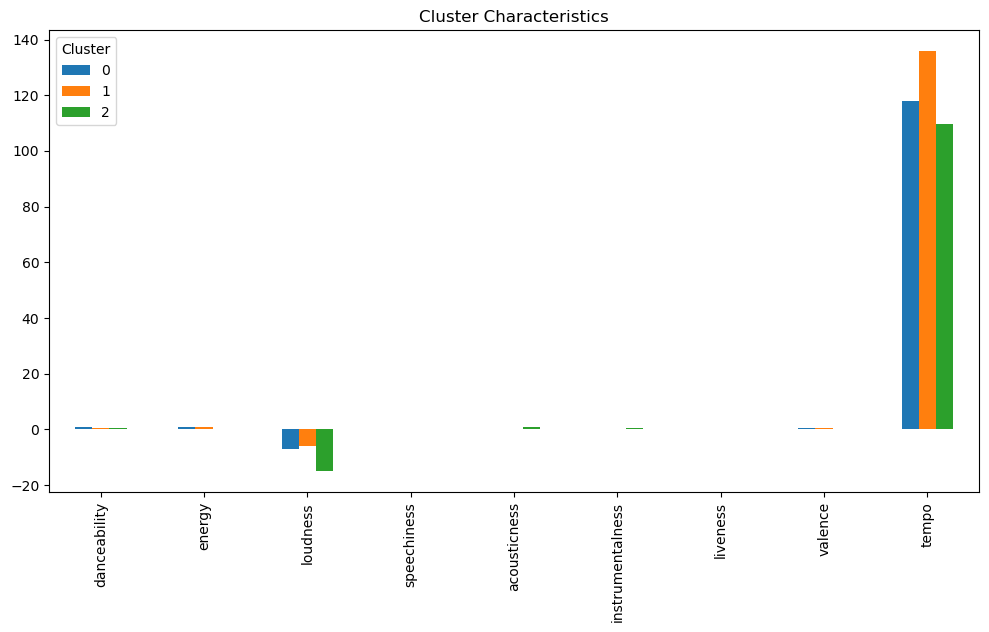

In [23]:
cluster_summary.T.plot(kind="bar", figsize=(12,6))
plt.title("Cluster Characteristics")
plt.legend(title="Cluster")
plt.show()

In [24]:
df_unique["cluster_name"] = df_unique["cluster"].map({
    0: "Chill",
    1: "Party",
    2: "Mixed"
})

### 🧠 Interpretation of Clusters

#### 🎵 Cluster 0 – Balanced Music
- Medium energy and danceability  
- Moderate tempo  
- Represents a mix of different song types  

👉 This cluster likely represents **general or mainstream music**.

---

#### 🔥 Cluster 1 – Loud & Intense Music
- Lower loudness (more negative values = quieter in technical scale)  
- Higher speechiness and acoustic variation  
- Slightly lower tempo  

👉 This cluster may represent **more complex or expressive music**, possibly including spoken elements or acoustic styles.

---

#### ⚡ Cluster 2 – High Tempo & Energetic Music
- Highest tempo  
- Higher energy and loudness  
- More dynamic sound  

👉 This cluster likely represents **energetic, fast-paced music (e.g., party or dance music)**.

### 🎯 Summary

We identified three main types of songs:

- 🎧 Balanced music (mixed characteristics)  
- 🎤 Expressive or acoustic-like music  
- 💃 Energetic and high-tempo music  

This shows that songs can be grouped based on their audio features, even without labels.

### 💼 Business Value

This type of clustering can be useful for:

- 🎯 Music recommendation systems  
- 🎶 Automatic playlist creation  
- 📈 Understanding listener preferences  
- 🎧 Improving user experience in streaming platforms like Spotify  

By grouping songs based on their characteristics, platforms can deliver more personalized content to users.

### 🚀 Conclusion

Using unsupervised machine learning, we were able to discover hidden patterns in the dataset and group songs into meaningful clusters.

This demonstrates the power of machine learning in understanding complex data without predefined labels.

## 📈 Advanced Analysis (Next Step)

In [ ]:
df_unique.groupby("cluster")["popularity"].mean()

cluster
0    34.098557
1    30.497917
2    33.745994
Name: popularity, dtype: float64

<Axes: xlabel='cluster', ylabel='popularity'>

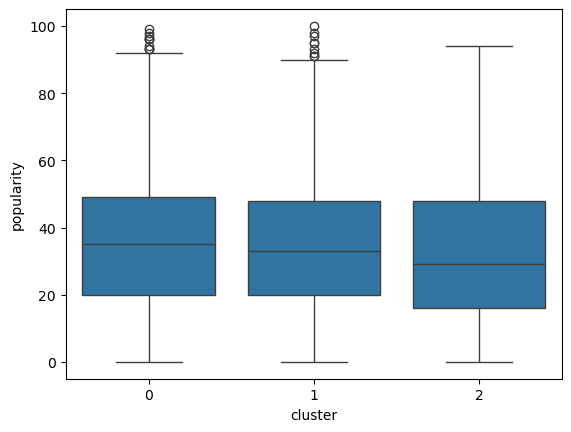

In [25]:
import seaborn as sns

sns.boxplot(x="cluster", y="popularity", data=df_unique)

### 📈 Cluster vs Popularity Analysis

We analyzed how song popularity differs across the clusters.

### 📊 Results

Average popularity per cluster:

- Cluster 0: ~34  
- Cluster 1: ~30  
- Cluster 2: ~33.7  

The differences are relatively small.

In [ ]:
### 🔍 Interpretation

The boxplot shows that all clusters have similar distributions of popularity.

There is no strong separation between clusters in terms of popularity.

### 🧠 Key Insight

Even though songs were grouped based on musical features, we did not observe a strong relationship between these features and popularity.

This suggests that popularity is influenced by many external factors, such as:

- Artist recognition  
- Marketing and promotion  
- Social media trends  
- Cultural context  